/tmp/ipykernel_9751/1787962215.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  bar = patches.Rectangle((0, 0), length, width, color='lightgray', edgecolor='black')
/tmp/ipykernel_9751/1787962215.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  hole = patches.Circle((x_hole, y_hole), radius, color='white', edgecolor='red')


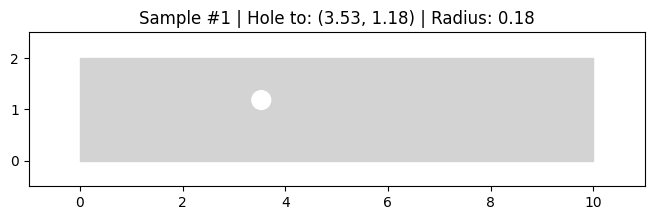

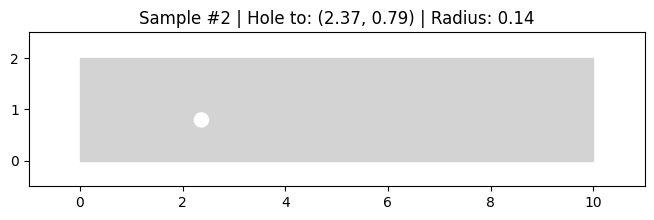

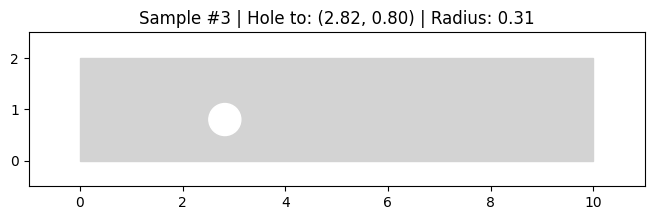

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def generate_geometry_sample(sample_id):
    # 1. Ορίζουμε τις διαστάσεις της ράβδου
    length = 10
    width = 2

    # 2. Παράγουμε τυχαία θέση και μέγεθος για την τρύπα
    # Το uniform(min, max) βγάζει έναν τυχαίο δεκαδικό αριθμό
    x_hole = random.uniform(1.5, 8.5)
    y_hole = random.uniform(0.5, 1.5)
    radius = random.uniform(0.1, 0.4)

    # 3. Δημιουργία του γραφήματος
    fig, ax = plt.subplots(figsize=(8, 2))

    # Σχεδιάζουμε τη ράβδο (γκρι ορθογώνιο)
    bar = patches.Rectangle((0, 0), length, width, color='lightgray', edgecolor='black')
    ax.add_patch(bar)

    # Σχεδιάζουμε την τρύπα (λευκός κύκλος)
    hole = patches.Circle((x_hole, y_hole), radius, color='white', edgecolor='red')
    ax.add_patch(hole)

    # Ρυθμίσεις εμφάνισης
    plt.xlim(-1, 11)
    plt.ylim(-0.5, 2.5)
    plt.title(f"Sample #{sample_id} | Hole to: ({x_hole:.2f}, {y_hole:.2f}) | Radius: {radius:.2f}")
    ax.set_aspect('equal')
    plt.show()

# Τρέχουμε το "εργοστάσιο" για 3 τυχαία δείγματαΛ
for i in range(1, 4):
    generate_geometry_sample(i)

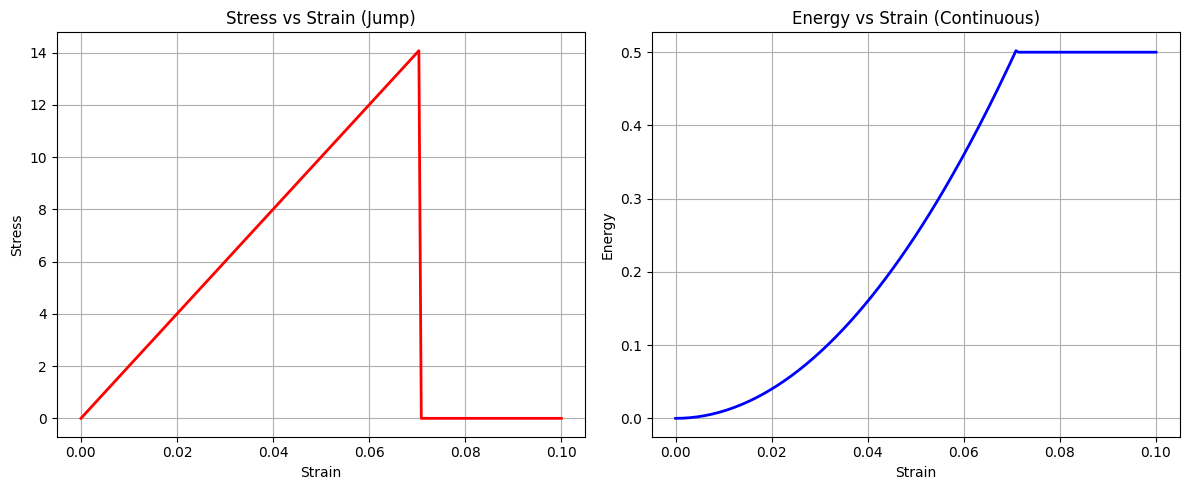

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_1d_fracture():
    # 1. Παράμετροι υλικού
    E = 200.0  # Μέτρο ελαστικότητας (πόσο σκληρό είναι)
    threshold_energy = 0.5  # Το όριο ενέργειας που αντέχει πριν σπάσει

    # 2. Δημιουργία της φόρτισης (τεντώνουμε από 0 έως 0.1)
    strain_steps = np.linspace(0, 0.1, 200)
    stress_history = []
    energy_history = []
    broken = False

    for strain in strain_steps:
        if not broken:
            # Υπολογισμός τάσης (Νόμος του Hooke: σ = Ε * ε)
            current_stress = E * strain
            # Υπολογισμός ενέργειας (U = 0.5 * σ * ε)
            current_energy = 0.5 * current_stress * strain

            # Έλεγχος αν έσπασε
            if current_energy > threshold_energy:
                broken = True
                current_stress = 0 # ΤΟ ΑΛΜΑ ΣΤΟ ΜΗΔΕΝ
        else:
            current_stress = 0
            current_energy = threshold_energy # Η ενέργεια μένει σταθερή (συνεχής)

        stress_history.append(current_stress)
        energy_history.append(current_energy)

    # 3. Εμφάνιση των αποτελεσμάτων
    plt.figure(figsize=(12, 5))

    # Γράφημα Τάσης - Το "Άλμα" (Jump)
    plt.subplot(1, 2, 1)
    plt.plot(strain_steps, stress_history, color='red', linewidth=2)
    plt.title("Stress vs Strain (Jump)")
    plt.xlabel("Strain")
    plt.ylabel("Stress")
    plt.grid(True)

    # Γράφημα Ενέργειας - Η "Συνέχεια" που έλεγε ο καθηγητής
    plt.subplot(1, 2, 2)
    plt.plot(strain_steps, energy_history, color='blue', linewidth=2)
    plt.title("Energy vs Strain (Continuous)")
    plt.xlabel("Strain")
    plt.ylabel("Energy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

simulate_1d_fracture()

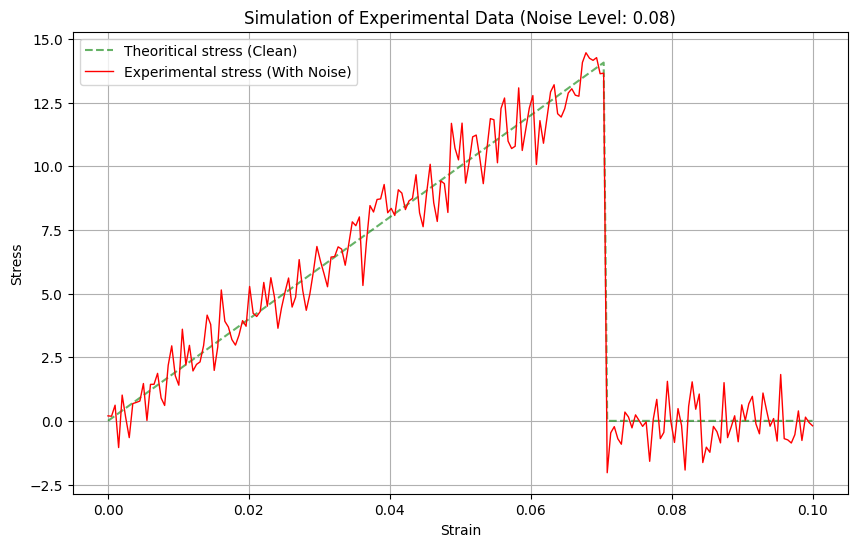

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_experimental_fracture(noise_level=0.05):
    # 1. Παράμετροι υλικού
    E = 200.0
    threshold_energy = 0.5

    # 2. Δημιουργία φόρτισης
    strain_steps = np.linspace(0, 0.1, 200)
    stress_clean = []
    broken = False

    for strain in strain_steps:
        if not broken:
            current_stress = E * strain
            if 0.5 * current_stress * strain > threshold_energy:
                broken = True
                current_stress = 0
        else:
            current_stress = 0
        stress_clean.append(current_stress)

    # 3. ΠΡΟΣΘΗΚΗ ΘΟΡΥΒΟΥ (Noise)
    # Δημιουργούμε τυχαία σφάλματα που εξαρτώνται από το noise_level
    noise = np.random.normal(0, noise_level * E * 0.05, len(stress_clean))
    stress_experimental = np.array(stress_clean) + noise

    # 4. Εμφάνιση των αποτελεσμάτων
    plt.figure(figsize=(10, 6))
    plt.plot(strain_steps, stress_clean, 'g--', label="Theoritical stress (Clean)", alpha=0.6)
    plt.plot(strain_steps, stress_experimental, 'r-', label="Experimental stress (With Noise)", linewidth=1)

    plt.title(f"Simulation of Experimental Data (Noise Level: {noise_level})")
    plt.xlabel("Strain")
    plt.ylabel("Stress")
    plt.legend()
    plt.grid(True)
    plt.show()

# Δοκίμασε να αλλάξεις το noise_level από 0.01 σε 0.2 για να δεις τη διαφορά!
simulate_experimental_fracture(noise_level=0.08)

In [18]:
import numpy as np
import pandas as pd
import random

def create_fracture_dataset(num_samples=100):
    all_data = []

    print(f"start generate {num_samples} samples...")

    for i in range(num_samples):
        # 1. Τυχαίες παράμετροι για κάθε "εικονική ράβδο"
        E = random.uniform(180, 220)           # Μέτρο ελαστικότητας
        threshold = random.uniform(0.3, 0.7)    # Αντοχή στη θραύση

        # 2. Τρέχουμε την προσομοίωση
        strain_steps = np.linspace(0, 0.1, 100)
        broken = False
        breaking_strain = 0.1 # Default αν δεν σπάσει

        for strain in strain_steps:
            current_energy = 0.5 * (E * strain) * strain
            if current_energy > threshold:
                breaking_strain = strain
                broken = True
                break # Σταματάμε μόλις σπάσει

        # 3. Αποθηκεύουμε τα χαρακτηριστικά (Features) και το αποτέλεσμα (Target)
        all_data.append({
            'sample_id': i,
            'elastic_modulus': E,
            'energy_threshold': threshold,
            'breaking_point_strain': breaking_strain, # Αυτό είναι το Target μας
            'is_broken': 1 if broken else 0
        })

    # 4. Μετατροπή σε Pandas DataFrame και αποθήκευση σε CSV
    df = pd.DataFrame(all_data)
    df.to_csv('fracture_data.csv', index=False)

    print("the file 'fracture_data.csv' generated!")
    return df

# Τρέξε το εργοστάσιο
dataset = create_fracture_dataset(100)

# Δείξε μας τις πρώτες 10 γραμμές του πίνακα
print("\n--- 10 first lines of Dataset ---")
print(dataset.head(10))

start generate 100 samples...
the file 'fracture_data.csv' generated!

--- 10 first lines of Dataset ---
   sample_id  elastic_modulus  energy_threshold  breaking_point_strain  \
0          0       202.615664          0.666163               0.081818   
1          1       192.171838          0.605410               0.079798   
2          2       219.888769          0.676311               0.078788   
3          3       195.161709          0.340435               0.059596   
4          4       210.295380          0.315091               0.055556   
5          5       191.350930          0.310969               0.057576   
6          6       182.335752          0.473917               0.072727   
7          7       204.117492          0.326080               0.056566   
8          8       180.613798          0.384700               0.065657   
9          9       196.185025          0.492430               0.071717   

   is_broken  
0          1  
1          1  
2          1  
3          1  
4    

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers

# 1. Φόρτωση των δεδομένων
df = pd.read_csv('fracture_data.csv')

# 2. Επιλογή Features (X) και Target (y)
X = df[['elastic_modulus', 'energy_threshold']].values
y = df['breaking_point_strain'].values

# 3. Διαχωρισμός σε δεδομένα Εκπαίδευσης (80%) και Τεστ (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Κανονικοποίηση (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Χτίσιμο του "Εγκεφάλου" (Νευρωνικό Δίκτυο)
model = tf.keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)), # 1ο επίπεδο (16 νευρώνες)
    layers.Dense(8, activation='relu'),                   # 2ο επίπεδο (8 νευρώνες)
    layers.Dense(1)                                       # Έξοδος (η πρόβλεψη)
])

# 6. Μεταγλώττιση
model.compile(optimizer='adam', loss='mse')

# 7. ΕΚΠΑΙΔΕΥΣΗ (Το AI "διαβάζει" το CSV 100 φορές)
print("The training started...")
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)
print("The training finished!")

# 8. Κάνουμε μια πρόβλεψη για μια ΝΕΑ ράβδο
new_rod = np.array([[210.0, 0.45]]) # Μια ράβδος που δεν είδε ποτέ το AI
new_rod_scaled = scaler.transform(new_rod)
prediction = model.predict(new_rod_scaled)

print(f"\nFor a rod with E=210 and Threshold=0.45:")
print(f"AI predictis the crack to Strain: {prediction[0][0]:.4f}")

The training started...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The training finished!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

For a rod with E=210 and Threshold=0.45:
AI predictis the crack to Strain: 0.0687


In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. ΔΗΜΙΟΥΡΓΙΑ ΦΑΣΜΑΤΙΚΩΝ ΔΕΔΟΜΕΝΩΝ (Synthetic Spectral Data)
def generate_spectral_data(samples=1000):
    data = []
    for _ in range(samples):
        # Τυχαία αντοχή
        strength = np.random.uniform(0.5, 1.0)

        # Προσομοιώνουμε 5 ιδιοτιμές (eigenvalues) που πέφτουν καθώς το φορτίο αυξάνεται
        # Όσο πλησιάζουμε στη θραύση (load -> strength), οι τιμές τείνουν στο 0
        current_load = np.random.uniform(0, strength)

        # Μαθηματικό μοντέλο φάσματος: λ_i = (strength - current_load) * i
        eigenvalues = [(strength - current_load) * i for i in range(1, 6)]

        # Πόσο μακριά είμαστε από το σπάσιμο; (Target: Distance to failure)
        distance_to_failure = strength - current_load

        data.append(eigenvalues + [distance_to_failure])

    return pd.DataFrame(data, columns=['eig1', 'eig2', 'eig3', 'eig4', 'eig5', 'target'])

# 2. ΠΡΟΕΤΟΙΜΑΣΙΑ
df = generate_spectral_data()
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. ΤΟ ΝΕΥΡΩΝΙΚΟ ΔΙΚΤΥΟ (Spectral Expert)
model = tf.keras.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mae')

# 4. ΕΚΠΑΙΔΕΥΣΗ
print(" AI studies eigenvalues...")
model.fit(X_train, y_train, epochs=50, verbose=0)
print("completed!")

# 5. ΤΕΣΤ: Δίνουμε στο AI ένα "περίεργο" φάσμα
sample_spectrum = np.array([[0.1, 0.2, 0.3, 0.4, 0.5]])
prediction = model.predict(sample_spectrum)

print(f"\n--- result of analysis ---")
print(f"eigenvalue entry: {sample_spectrum[0]}")
print(f"prdict AI: the crack will be {prediction[0][0]:.4f} Coulob.")

 AI studies eigenvalues...
completed!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

--- result of analysis ---
eigenvalue entry: [0.1 0.2 0.3 0.4 0.5]
prdict AI: the crack will be 0.1002 Coulob.


We transition from manually computed eigenvalues to a fully data-driven feature set by concatenating the raw rod data with key geometric descriptors (minimum defect, mean quality, and defect location).We apply a Random Forest Regressor to predict the failure strain and extract feature importances, verifying the model's ability to autonomously identify the critical role of the maximum defect.

Επιβεβαίωση Διαστάσεων -> X: (1000, 103), y: (1000,)
train
Ακρίβεια Μοντέλου (R^2 Score): 0.9999


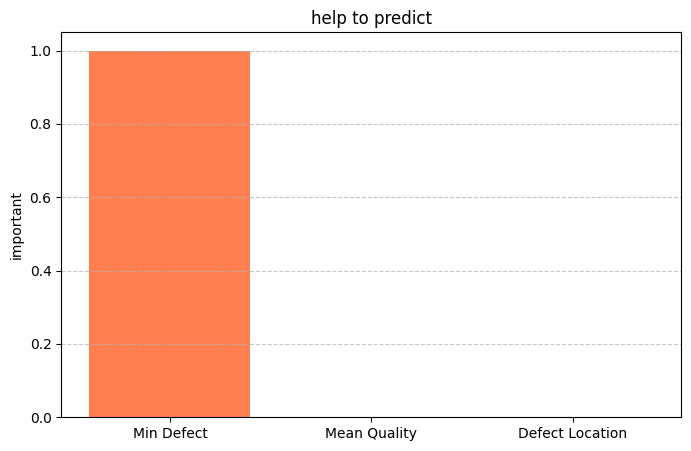

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Function to generate synthetic rod data with a single defect
def generate_rod_data(num_samples=1000, num_points=100):
    all_rods = []
    for _ in range(num_samples):
        rod = np.ones(num_points)  # Start with a perfect rod (value 1.0)
        # Introduce a single defect
        pos = np.random.randint(0, num_points)  # Random position of the defect
        depth = np.random.uniform(0.1, 0.9)  # Random depth of the defect
        # Create a small affected area around the defect position
        width = np.random.randint(1, 5)
        start = max(0, pos - width // 2)
        end = min(num_points, pos + width // 2 + 1)
        rod[start:end] = np.minimum(rod[start:end], 1.0 - depth) # Ensure defect reduces value
        all_rods.append(rod)
    return all_rods

# Generate 1000 rods for the simulation
rods = generate_rod_data(num_samples=1000, num_points=100)

X_new = []
y_new = []


for rod in rods:
    # Αντί για ιδιοτιμές, βγάζουμε τα γεωμετρικά χαρακτηριστικά
    min_val = np.min(rod)
    mean_val = np.mean(rod)
    pos_min = np.argmin(rod)


    features = np.concatenate([[min_val, mean_val, pos_min], rod])
    X_new.append(features)

    # TARGET (y): Υπολογίζουμε το strain για την ΙΔΙΑ ράβδο την ίδια στιγμή

    strain = 1.0 / (min_val + 0.0001)
    y_new.append(strain)

# Μετατροπή σε Numpy Arrays
X = np.array(X_new)
y = np.array(y_new)

print(f"Επιβεβαίωση Διαστάσεων -> X: {X.shape}, y: {y.shape}")

# RANDOM FOREST
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("train")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


score = rf_model.score(X_test, y_test)
print(f"Ακρίβεια Μοντέλου (R^2 Score): {score:.4f}")


importances = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(['Min Defect', 'Mean Quality', 'Defect Location'], importances[:3], color='coral')
plt.title("help to predict")
plt.ylabel("important")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

we increase complexity by introducing three random defects of varying depths and widths within the same rod. The objective is to verify if the model follows the "Weakest Link" principle—identifying that failure is governed strictly by the deepest defect, while ignoring secondary, less critical imperfections.

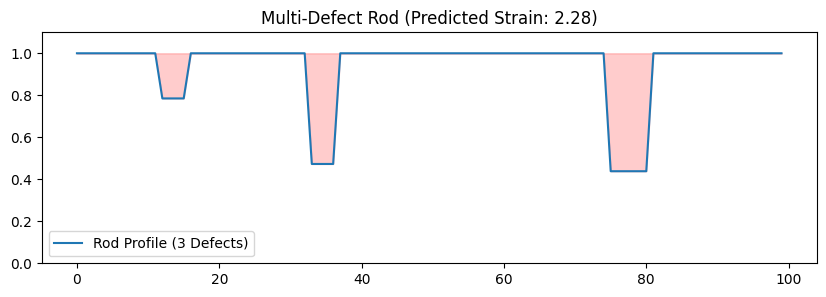

Accuracy on Multi-Defect dataset: 1.0000


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# --- ΒΗΜΑ 1: ΠΑΡΑΓΩΓΗ ΔΕΔΟΜΕΝΩΝ ΜΕ ΠΟΛΛΑΠΛΕΣ ΤΡΥΠΕΣ ---
def generate_multi_defect_rod(num_points=100, num_holes=3):
    # Ξεκινάμε με μια "τέλεια" ράβδο (τιμή 1.0 παντού)
    rod = np.ones(num_points)
    for _ in range(num_holes):
        pos = np.random.randint(0, num_points)
        depth = np.random.uniform(0.1, 0.8) # Τυχαίο βάθος τρύπας
        # Δημιουργούμε μια μικρή περιοχή ελαττώματος γύρω από τη θέση
        width = np.random.randint(1, 4)
        start = max(0, pos - width)
        end = min(num_points, pos + width)
        rod[start:end] = np.minimum(rod[start:end], 1.0 - depth)
    return rod

# Δημιουργούμε 1000 νέες ράβδους
X_multi = []
y_multi = []

for _ in range(1000):
    rod = generate_multi_defect_rod()
    # Εξαγωγή Χαρακτηριστικών (Geometric Descriptors)
    min_val = np.min(rod)       # Το πιο βαθύ ελάττωμα (το πιο κρίσιμο)
    mean_val = np.mean(rod)     # Η γενική κατάσταση
    std_val = np.std(rod)       # Η ανομοιομορφία

    features = np.concatenate([[min_val, mean_val, std_val], rod])
    X_multi.append(features)

    # Το strain εξαρτάται πάντα από το χειρότερο σημείο (min_val)
    strain = 1.0 / (min_val + 0.0001)
    y_multi.append(strain)

X_multi = np.array(X_multi)
y_multi = np.array(y_multi)

# --- ΒΗΜΑ 2: ΕΚΠΑΙΔΕΥΣΗ ΜΟΝΤΕΛΟΥ ---
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
rf_multi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_multi.fit(X_train, y_train)

# --- ΒΗΜΑ 3: ΟΠΤΙΚΟΠΟΙΗΣΗ ΜΙΑΣ ΡΑΒΔΟΥ ---
plt.figure(figsize=(10, 3))
plt.plot(X_multi[0, 3:], label="Rod Profile (3 Defects)")
plt.fill_between(range(100), X_multi[0, 3:], 1, color='red', alpha=0.2)
plt.title(f"Multi-Defect Rod (Predicted Strain: {rf_multi.predict(X_multi[0:1])[0]:.2f})")
plt.ylim(0, 1.1)
plt.legend()
plt.show()

print(f"Accuracy on Multi-Defect dataset: {rf_multi.score(X_test, y_test):.4f}")

we simulate a realistic environment by adding stochastic background noise across the entire rod, representing material roughness or market volatility. We then introduce a single critical defect. By analyzing the "Feature Importance" of the Random Forest, we demonstrate the model's capacity to filter out background noise and autonomously lock onto the signal (the critical defect) that triggers the catastrophic transition.

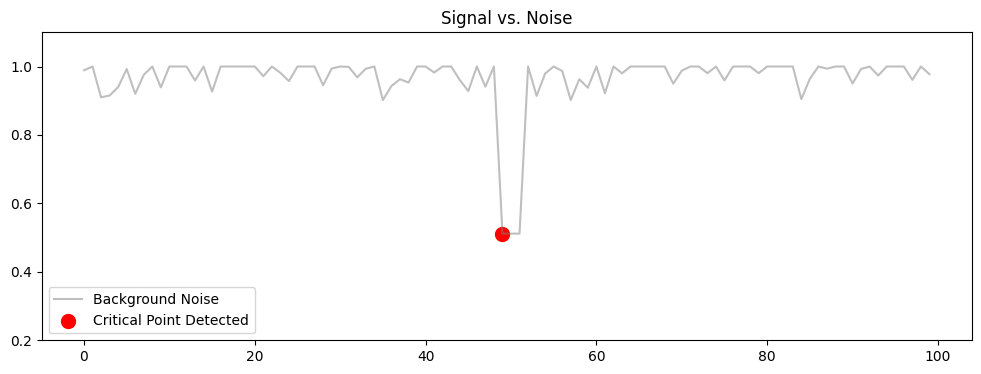

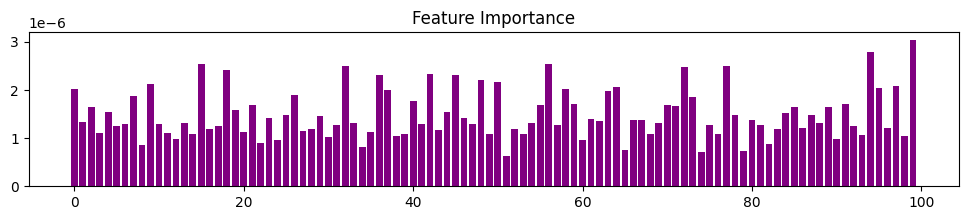

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

def generate_noisy_critical_rod(num_points=100):
    # 1. Background Noise (Μικρο-ελαττώματα παντού)
    # Προσομοιώνει τη φυσική ατέλεια του υλικού ή το "market noise"
    rod = 1.0 - np.random.normal(0, 0.05, num_points)
    rod = np.clip(rod, 0.85, 1.0)

    # 2. Το Κρίσιμο Ελάττωμα (The Critical Defect)
    # Αυτό είναι που θα προκαλέσει τη θραύση
    critical_pos = np.random.randint(5, 95)
    critical_depth = np.random.uniform(0.3, 0.7)
    rod[critical_pos-1 : critical_pos+2] = 1.0 - critical_depth

    return rod, critical_pos

# Δημιουργία Dataset
X_noise = []
y_noise = []

for _ in range(1000):
    rod, _ = generate_noisy_critical_rod()
    # Features: Ολόκληρη η ράβδος + Στατιστικά
    features = np.concatenate([[np.min(rod), np.mean(rod)], rod])
    X_noise.append(features)
    y_noise.append(1.0 / (np.min(rod) + 0.0001))

X_noise = np.array(X_noise)
y_noise = np.array(y_noise)

# Εκπαίδευση
X_train, X_test, y_train, y_test = train_test_split(X_noise, y_noise, test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# ΟΠΤΙΚΟΠΟΙΗΣΗ ΤΟΥ "ΣΗΜΑΤΟΣ ΜΕΣΑ ΣΤΟ ΘΟΡΥΒΟ"
plt.figure(figsize=(12, 4))
sample_rod = X_noise[0, 2:]
plt.plot(sample_rod, color='gray', alpha=0.5, label="Background Noise")
plt.scatter(np.argmin(sample_rod), np.min(sample_rod), color='red', s=100, label="Critical Point Detected")
plt.title("Signal vs. Noise")
plt.ylim(0.2, 1.1)
plt.legend()
plt.show()

# ΔΕΙΞΕ ΤΟ FEATURE IMPORTANCE )
importances = model.feature_importances_[2:]
plt.figure(figsize=(12, 2))
plt.bar(range(100), importances, color='purple')
plt.title("Feature Importance")
plt.show()